# Rank Percentile Score Validation
## Comparing three normalisation approaches for binder–decoy discrimination

**Experiment:** For each docked molecule we compute three normalised scores and compare how well each separates **known binders** from **decoys**.

| Score | Description |
|---|---|
| **Rank percentile** | Molecules are ranked within their protein's full distribution and mapped 0→1. |
| **Per-protein min-max** | Raw Vina score min-max scaled per protein (inverted, 1 = best). |
| **Z-score (decoy-referenced)** | Vina score z-scored against decoy distribution, mapped via Φ(−z) to 0→1. |

### Data sources
* **`drrp_scores_combined.txt`** — **decoys only** from previous runs.
* **`drrp_scores.txt`** (knownbindersvinarun) — known binders docked fresh on the same proteins.

In [ ]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde

warnings.filterwarnings("ignore")

# ── Paths ─────────────────────────────────────────────────────────────────────
COMBINED_SCORES_PATH = Path("scores_combined.txt")
KB_RUN_DIR           = Path("knownbindersvinarun")
KB_GUILD_SCORES_PATH = KB_RUN_DIR / "drrp_scores.txt"

OUT_DIR = Path("np_synthetic_comparison/guild_figures")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Legacy column rename map (drrp → rp) ─────────────────────────────────────
LEGACY_RENAME = {
    "drrp_vina_score": "rp_vina_score",
    "drrp_diffdock_score": "rp_diffdock_score",
    "drrp_boltz_score": "rp_boltz_score",
    "drrp_karmadock_score": "rp_karmadock_score",
    "global_drrp_score": "global_rp_score",
    "dockwizard_vina_score": "rp_vina_score",
    "guild_vina_score": "rp_vina_score",
    "global_guild_score": "global_rp_score",
}

# ── Palette ───────────────────────────────────────────────────────────────────
COLORS = {
    "decoy":          "#999999",
    "known-binder":   "#e07b39",   # orange — both strong + weak collapsed
    "strong-binder":  "#c0392b",
    "weak-binder":    "#e07b39",
    "Natural Product":"#2ecc71",
    "Synthetic":      "#3498db",
}
print("Paths configured ✓")

Paths configured ✓


In [6]:
# ── Proteins to exclude ───────────────────────────────────────────────────────
EXCLUDE_PROTEINS = {"7v6a", "8fx5", "8wrz", "8wu1", "8dzs"}

# ── Load scores_combined.txt — decoys only ───────────────────────────────────
combined = pd.read_csv(COMBINED_SCORES_PATH, sep="\t")
combined = combined.rename(columns=LEGACY_RENAME)
combined = combined[combined["ligand_category"] == "decoy"].copy()
combined["group"]  = "decoy"
combined["source"] = "combined"
print(f"Decoys loaded: {len(combined):,} rows")

# ── Load known-binders run scores ─────────────────────────────────────────────
if not KB_GUILD_SCORES_PATH.exists():
    raise FileNotFoundError(f"KB run not found: {KB_GUILD_SCORES_PATH}")

kb_scores = pd.read_csv(KB_GUILD_SCORES_PATH, sep="\t")
kb_scores = kb_scores.rename(columns=LEGACY_RENAME)
kb_scores["group"]  = "known-binder"
kb_scores["source"] = "kb_run"
print(f"Known-binders loaded: {len(kb_scores):,} rows")

# ── Build unified dataframe ───────────────────────────────────────────────────
unified = pd.concat([combined, kb_scores], ignore_index=True)

# ── Exclude proteins ─────────────────────────────────────────────────────────
unified["pdb_id"] = unified["protein_config_id"].str.split("-").str[0]
unified = unified[~unified["pdb_id"].isin(EXCLUDE_PROTEINS)].copy()
print(f"Unified dataset (after excluding {EXCLUDE_PROTEINS}): {len(unified):,} rows")
print(unified["group"].value_counts())

Decoys loaded: 133,266 rows
Known-binders loaded: 655 rows
Unified dataset (after excluding {'7v6a', '8fx5', '8dzs', '8wu1', '8wrz'}): 128,886 rows
group
decoy           128256
known-binder       630
Name: count, dtype: int64


In [7]:
from scipy.stats import norm as scipy_norm
from scipy.stats import percentileofscore

from guild.tools.scores import compute_rank_percentile_scores

# ── Keep only rows with a valid vina score ────────────────────────────────────
unified = unified[unified["vina_score"].notna()].copy()
print(f"Rows with valid vina score: {len(unified):,}")
print(unified["group"].value_counts())

# ── Compute rank percentile scores via the package function ─────────────────────────────
# Adds rank_vina_score and rp_vina_score columns per protein.
# rp_vina_score = rank / N  (0→1, lower = better; rank 1 = most negative Vina)
unified = compute_rank_percentile_scores(unified, methods=["vina"])

# ── Per-protein min-max normalisation of raw Vina (comparison baseline) ───────
def _minmax_invert(grp):
    lo, hi = grp.min(), grp.max()
    return (hi - grp) / (hi - lo) if hi != lo else pd.Series(0.5, index=grp.index)

unified["vina_min_max"] = unified.groupby("protein_config_id")["vina_score"].transform(_minmax_invert)

# ── Decoy-referenced rank percentile ─────────────────────────────────────────
# For each molecule: what fraction of *decoys* (same protein) have a worse Vina score?
# Inverted so 1 = better than all decoys.
def _decoy_pct(grp):
    decoy_vina = grp.loc[grp["group"] == "decoy", "vina_score"].dropna().values
    if len(decoy_vina) < 2:
        return pd.Series(0.5, index=grp.index)
    return grp["vina_score"].apply(
        lambda v: 1.0 - percentileofscore(decoy_vina, v, kind="rank") / 100.0
        if pd.notna(v) else float("nan")
    )

unified["decoy_pct"] = (
    unified.groupby("protein_config_id", group_keys=False).apply(_decoy_pct)
)

# ── Standard z-score → normal CDF → [0, 1] ───────────────────────────────────
# Mean and std estimated from ALL molecules per protein; lower Vina = better, so −z is used.
def _zscore(grp):
    scores = grp["vina_score"].dropna()
    if len(scores) < 2:
        return pd.Series(0.5, index=grp.index)
    mu, sigma = scores.mean(), scores.std()
    if sigma == 0:
        return pd.Series(0.5, index=grp.index)
    z = (grp["vina_score"].values - mu) / sigma
    return pd.Series(scipy_norm.cdf(-z), index=grp.index)

unified["zscore_norm"] = (
    unified.groupby("protein_config_id", group_keys=False).apply(_zscore)
)

# ── Unbounded decoy-fitted rank percentile ────────────────────────────────────
# Phase 1: Rank decoys only per protein (1 = best binder).
# Phase 2: Proportion = rank / N_decoys.
# Phase 3: Place ALL molecules on the decoy scale (no clipping).
#   → known binders that beat all decoys get values < 1/N (below 0 when inverted to 1-best).
#   → known binders worse than all decoys get values > 1.
def _decoy_fit_unbounded(grp):
    decoy_vina = grp.loc[grp["group"] == "decoy", "vina_score"].dropna().values
    n_decoys = len(decoy_vina)
    if n_decoys < 2:
        return pd.Series(np.nan, index=grp.index)

    def _rank_against_decoys(v):
        if pd.isna(v):
            return np.nan
        better_than = np.sum(decoy_vina > v)
        ties = np.sum(decoy_vina == v)
        rank = n_decoys - better_than - 0.5 * ties + 0.5
        return rank / n_decoys

    return grp["vina_score"].apply(_rank_against_decoys)

unified["decoy_fit_unbounded"] = (
    unified.groupby("protein_config_id", group_keys=False).apply(_decoy_fit_unbounded)
)

print(f"\nRows after scoring: {len(unified):,}")
print(f"rp_vina_score range        : {unified['rp_vina_score'].min():.4f} – {unified['rp_vina_score'].max():.4f}")
print(f"vina_min_max range         : {unified['vina_min_max'].min():.4f} – {unified['vina_min_max'].max():.4f}")
print(f"decoy_pct range            : {unified['decoy_pct'].min():.4f} – {unified['decoy_pct'].max():.4f}")
print(f"zscore_norm range          : {unified['zscore_norm'].min():.4f} – {unified['zscore_norm'].max():.4f}")
print(f"decoy_fit_unbounded range  : {unified['decoy_fit_unbounded'].min():.4f} – {unified['decoy_fit_unbounded'].max():.4f}")
print(unified[["protein_config_id", "vina_score", "rp_vina_score", "vina_min_max", "decoy_pct", "zscore_norm", "decoy_fit_unbounded", "group"]].head(6))

Rows with valid vina score: 98,989
group
decoy           98769
known-binder      220
Name: count, dtype: int64

Rows after scoring: 98,989
rp_vina_score range        : 0.0010 – 1.0000
vina_min_max range         : 0.0000 – 1.0000
decoy_pct range            : 0.0000 – 0.9990
zscore_norm range          : 0.0000 – 1.0000
decoy_fit_unbounded range  : 0.0010 – 1.0005
  protein_config_id  vina_score  rp_vina_score  vina_min_max  decoy_pct  \
0      8gut-R-KO8-R      -8.059       0.682531      0.467463   0.318468   
1      8ge3-R-G1I-R  267850.769       0.847849      0.988042   0.152151   
2      3v2w-A-ML5-A      -7.518       0.348374      0.999983   0.651626   
3      3odu-A-ITD-A      -8.142       0.550892      0.526181   0.449108   
4      5unh-A-8EM-A      -7.651       0.825813      0.097990   0.174187   
5      7dhi-R-68H-R      -3.807       0.666316      0.999998   0.333684   

   zscore_norm  decoy_fit_unbounded  group  
0     0.419863             0.681532  decoy  
1     0.551802      

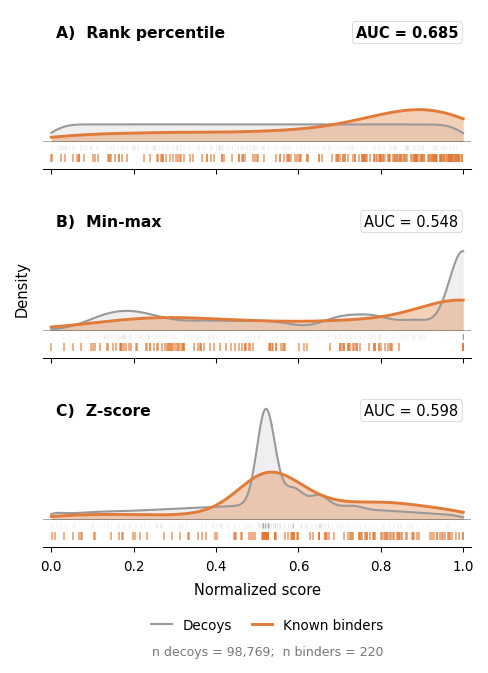

Saved PNG / PDF / SVG in np_synthetic_comparison/guild_figures


In [8]:

import matplotlib as mpl
from sklearn.metrics import roc_auc_score

# ── Publication-ready defaults (double-column manuscript) ─────────────────────
mpl.rcParams.update(mpl.rcParamsDefault)
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 7,
    "axes.titlesize": 8,
    "axes.titleweight": "bold",
    "axes.labelsize": 7,
    "xtick.labelsize": 6.5,
    "ytick.labelsize": 6.5,
    "legend.fontsize": 6.5,
    "axes.linewidth": 0.5,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "xtick.major.size": 2.5,
    "ytick.major.size": 2.5,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.transparent": False,
    "figure.dpi": 150,
})

# ── Sample sizes ──────────────────────────────────────────────────────────────
plot_decoys  = unified[unified["group"] == "decoy"]
plot_binders = unified[unified["group"] == "known-binder"]
N_DECOYS  = len(plot_decoys)
N_BINDERS = len(plot_binders)

# ── Helper functions ──────────────────────────────────────────────────────────
def kde_curve(values, x_grid, bw="scott"):
    values = np.asarray(values.dropna())
    if len(values) < 2:
        return np.zeros_like(x_grid)
    return gaussian_kde(values, bw_method=bw)(x_grid)

def _auc(decoy_vals, kb_vals):
    y_true  = np.concatenate([np.zeros(len(decoy_vals)), np.ones(len(kb_vals))])
    y_score = np.concatenate([decoy_vals, kb_vals])
    mask    = ~np.isnan(y_score)
    if mask.sum() < 2 or len(np.unique(y_true[mask])) < 2:
        return float("nan")
    return roc_auc_score(y_true[mask], y_score[mask])

# ── Prepare data ─────────────────────────────────────────────────────────────
guild_decoy = (1 - plot_decoys["rp_vina_score"]).dropna()
guild_kb    = (1 - plot_binders["rp_vina_score"]).dropna()
norm_decoy  = plot_decoys["vina_min_max"].dropna()
norm_kb     = plot_binders["vina_min_max"].dropna()
zsc_decoy   = plot_decoys["zscore_norm"].dropna()
zsc_kb      = plot_binders["zscore_norm"].dropna()

# (decoy_vals, kb_vals, panel_title, is_highlight)
panels = [
    (guild_decoy, guild_kb, "Rank percentile",             True),
    (norm_decoy,  norm_kb,  "Min-max",                     False),
    (zsc_decoy,   zsc_kb,   "Z-score",                     False),
]

panel_labels = ["A)", "B)", "C)"]

# ── Shared y-scale ───────────────────────────────────────────────────────────
x_grid = np.linspace(0, 1, 400)
kmax = max(
    *(kde_curve(d, x_grid).max() for d, _, _, _ in panels),
    *(kde_curve(k, x_grid).max() for _, k, _, _ in panels),
    1e-9,
)

# ── 3×1 vertical figure ─────────────────────────────────────────────────────
fig, axes = plt.subplots(
    3, 1,
    figsize=(3.4, 4.8),
    sharex=True,
    sharey=True,
    gridspec_kw={"hspace": 0.22},
)

for idx, (ax, (dec_vals, kb_vals, title, highlight)) in enumerate(zip(axes, panels, strict=False)):
    kd = kde_curve(dec_vals, x_grid)
    kb = kde_curve(kb_vals,  x_grid)

    # KDE fills + lines
    ax.fill_between(x_grid, 0, kd, color=COLORS["decoy"],        alpha=0.15, linewidth=0)
    ax.plot(x_grid, kd, color=COLORS["decoy"],        lw=1.0, label="Decoys")
    ax.fill_between(x_grid, 0, kb, color=COLORS["known-binder"], alpha=0.35, linewidth=0)
    ax.plot(x_grid, kb, color=COLORS["known-binder"], lw=1.4, label="Known binders")

    # Zero line
    ax.axhline(0, color="black", lw=0.4, alpha=0.4)

    # Rug: decoys (subsample)
    for v in dec_vals.sample(min(400, len(dec_vals)), random_state=42):
        ax.plot([v, v], [-kmax*0.03, -kmax*0.08], color=COLORS["decoy"],
                lw=0.3, alpha=0.10, solid_capstyle="butt")
    # Rug: binders
    for v in kb_vals:
        ax.plot([v, v], [-kmax*0.11, -kmax*0.19], color=COLORS["known-binder"],
                lw=0.8, alpha=0.70, solid_capstyle="butt")

    # Panel label + title (top-left)
    ax.text(
        0.03, 0.93, f"{panel_labels[idx]}  {title}",
        transform=ax.transAxes, fontsize=7.5, fontweight="bold",
        va="top", ha="left",
    )

    # AUC annotation (top-right) — bold only for rank percentile (panel A)
    auc = _auc(dec_vals.values, kb_vals.values)
    auc_weight = "bold" if highlight else "normal"
    ax.text(
        0.97, 0.93, f"AUC = {auc:.3f}",
        transform=ax.transAxes, fontsize=7, fontweight=auc_weight,
        va="top", ha="right",
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white",
                  edgecolor="#cccccc", alpha=0.85, linewidth=0.4),
    )

    # Axes cosmetics
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-kmax * 0.25, kmax * 1.15)
    ax.tick_params(axis="y", left=False, labelleft=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

    if idx < 2:
        ax.tick_params(axis="x", labelbottom=False)
    else:
        ax.set_xlabel("Normalized score", labelpad=4)

# Shared legend below the bottom panel
legend_handles = [
    Line2D([0], [0], color=COLORS["decoy"],        lw=1.0, label="Decoys"),
    Line2D([0], [0], color=COLORS["known-binder"], lw=1.4, label="Known binders"),
]
fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=2,
    bbox_to_anchor=(0.5, 0.005),
    frameon=False,
    columnspacing=1.5,
    handlelength=1.5,
)

# Shared y-axis label
fig.text(
    0.005, 0.5, "Density",
    va="center", ha="left", rotation="vertical", fontsize=7,
)
fig.subplots_adjust(left=0.06, bottom=0.14)

# Sample size annotation
fig.text(
    0.5, -0.01,
    f"n decoys = {N_DECOYS:,};  n binders = {N_BINDERS:,}",
    ha="center", fontsize=6, color="#777777",
)

# Save in multiple formats
for ext in ("png", "pdf", "svg"):
    out = OUT_DIR / f"figure_3_validation_three_normalisations.{ext}"
    fig.savefig(out, dpi=600, bbox_inches="tight")

plt.show()
print(f"Saved PNG / PDF / SVG in {OUT_DIR}")
